In [1]:
from sklearn.neighbors import NearestNeighbors
import glob
import pandas as pd
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt


In [2]:
model = ['llr', 'llr_filtered', 'xgb', 'xgb_filtered']
col = {'llr':'', 'llr_filtered':'_llr_filtered', 'xgb':'_xgb_origin', 'xgb_filtered':'_xgb_filtered'}

In [3]:
target = pd.read_csv('../all_sample_20260702.csv')
tg_z = (target.paliya_Z).values
tg_d = Planck18.comoving_distance(target.paliya_Z).value
tg_ra = (target.paliya_RA).values
tg_dec = (target.paliya_DEC).values

coord = SkyCoord(ra = tg_ra * u.deg, dec = tg_dec * u.deg, distance = tg_d * u.Mpc)
tg_df = pd.DataFrame({'coord':coord})

In [16]:
dens_df = pd.DataFrame()
for m in model:
    def compute_index_for_i(i):
        file_list = glob.glob(f'../data/catalog/ps1/matched/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
        if len(file_list) == 0:
            return -999

        target_z = float(target.paliya_Z.iloc[i])
        df = pd.read_csv(file_list[0])

        z_window = (
            z_at_value(Planck18.comoving_distance, (tg_d[i] + 5) * u.Mpc)
            - z_at_value(Planck18.comoving_distance, (tg_d[i] - 5) * u.Mpc)
        )
        # df = df[np.isfinite(df.z_phot0) & np.isfinite(df.z_photErr)]
        # df = df[np.abs(df.z_phot0 - target_z) < z_window]

        if len(df) == 0:
            return -999

        surround_z = df[f'z_phot{col[m]}'].to_numpy(dtype=float)
        surround_err = df[f'z_phot_err{col[m]}'].to_numpy(dtype=float)
        surround_ra = df.raMean.to_numpy(dtype=float)
        surround_dec = df.decMean.to_numpy(dtype=float)

        mask = (surround_z - surround_err / 2) > -1
        surround_z = surround_z[mask]
        surround_err = surround_err[mask]
        surround_ra = surround_ra[mask]
        surround_dec = surround_dec[mask]

        if len(surround_z) == 0:
            return -999

        surround_d = Planck18.comoving_distance(surround_z).value
        valid = np.isfinite(surround_d) & (surround_d >= 0)
        surround_z = surround_z[valid]
        surround_err = surround_err[valid]
        surround_ra = surround_ra[valid]
        surround_dec = surround_dec[valid]
        surround_d = surround_d[valid]

        if len(surround_d) == 0:
            return -999

        z_low = np.maximum(surround_z - surround_err / 2, 0)
        surround_scale = (
            Planck18.comoving_distance(surround_z + surround_err / 2)
            - Planck18.comoving_distance(z_low)
        ).value
        surround_odds = np.abs(
            norm.cdf(Planck18.comoving_distance(tg_z[i] - 1000/300000), loc=surround_d, scale=surround_scale)
            - norm.cdf(Planck18.comoving_distance(tg_z[i] + 1000/300000), loc=surround_d, scale=surround_scale)
        )

        coord_1 = SkyCoord(ra=surround_ra * u.deg, dec=surround_dec * u.deg, distance=surround_d * u.Mpc)
        target_coord = coord[i]

        df_surround = target_coord.separation(coord_1)
        df_surround = df_surround.to_value(u.rad) * tg_d[i]
        X = np.asarray(df_surround, dtype=float).reshape(-1, 1)
        nn = NearestNeighbors(n_neighbors=max(1, min(int(len(X) / 2), len(X))), algorithm='auto')
        nn.fit(X)
        neighbors = nn.kneighbors(np.array([[0]]))
        k_index = np.where(np.cumsum(surround_odds[neighbors[1][0]]) >= 5)[0]
        if len(k_index) == 0:
            return -999

        index = neighbors[1][0][:k_index[0]]
            
        row = df.distance.iloc[index] / 60
        row = np.deg2rad(row)
        fifth_dis = row * tg_d[i]
        fifth_dis = (fifth_dis**2) * surround_odds[index]
        fifth_dens = np.sum(surround_odds[index]) / np.pi / np.sum(fifth_dis)
        fifth_dens = np.log(fifth_dens)
        return fifth_dens

    dens = np.array(Parallel(n_jobs=-1, verbose=5)(delayed(compute_index_for_i)(i) for i in range(len(tg_df))))
    dens_df[f'dens_{m}'] = [dens]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 268 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 492 out of 492 | elapsed:   13.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 450 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 473 out of 492 | elapsed:    4.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 492 out of 492 | elapsed:    4.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elaps

In [17]:
llr_dens = dens_df.dens_llr[0][dens_df.dens_llr[0] != -999]
llr_filtered_dens = dens_df.dens_llr_filtered[0][dens_df.dens_llr_filtered[0] != -999]
xgb_dens = dens_df.dens_xgb[0][dens_df.dens_xgb[0] != -999]
xgb_filtered_dens = dens_df.dens_xgb_filtered[0][dens_df.dens_xgb_filtered[0] != -999]

In [18]:
np.save('./llr_dens.npy', llr_dens)
np.save('./xgb_dens.npy', xgb_dens)

In [19]:
# dens = []
# for i, idx in enumerate(llr_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


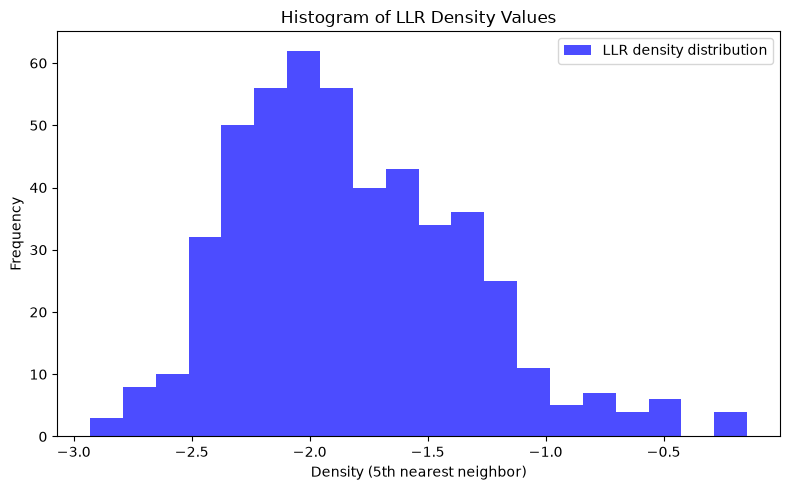

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(llr_dens, bins=20, label='LLR density distribution', color='blue', alpha=0.7)
plt.xlabel('Density (5th nearest neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of LLR Density Values')
plt.legend()
plt.tight_layout()
plt.savefig(f'../fig/llr_density_histogram.png', dpi=300)
plt.show()

In [21]:
# dens = []
# for i, idx in enumerate(xgb_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


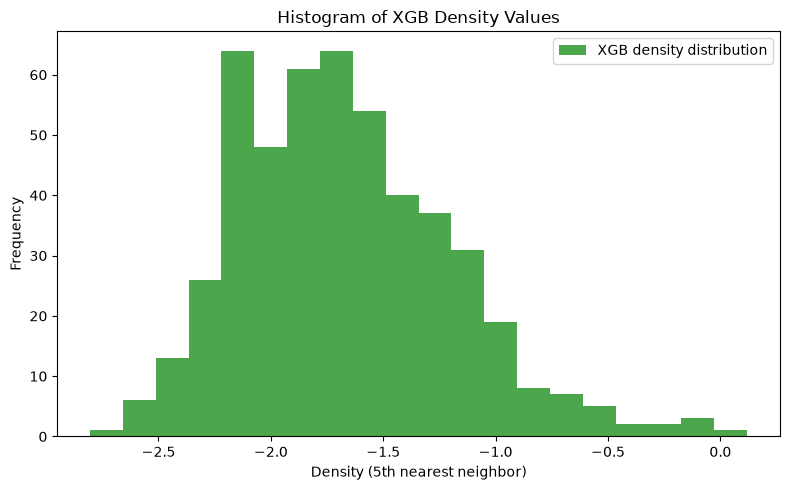

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(xgb_dens, bins=20, label='XGB density distribution', color='green', alpha=0.7)
plt.xlabel('Density (5th nearest neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of XGB Density Values')
plt.legend()
plt.tight_layout()
plt.savefig(f'../fig/xgb_density_histogram.png', dpi=300)
plt.show()

In [23]:
# dens = []
# for i, idx in enumerate(llr_filtered_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)

In [24]:
# plt.figure(figsize=(8, 5))
# plt.hist(llr_filtered_dens, bins=10, label='LLR filtered density distribution', color='orange', alpha=0.7)
# plt.xlabel('Density (5th nearest neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of LLR Filtered Density Values')
# plt.legend()
# plt.tight_layout()
# plt.savefig(f'../fig/llr_filtered_density_histogram_{len(glob.glob("../fig/*.png"))}.png', dpi=300)
# plt.show()

In [25]:
# dens = []
# for i, idx in enumerate(xgb_filtered_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/merged/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


In [26]:
# plt.figure(figsize=(8, 5))
# plt.hist(xgb_filtered_dens, bins=10, label='XGB filtered density distribution', color='purple', alpha=0.7)
# plt.xlabel('Density (5th nearest neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of XGB Filtered Density Values')
# plt.legend()
# plt.tight_layout()
# plt.savefig(f'../fig/xgb_filtered_density_histogram_{len(glob.glob("../fig/*.png"))}.png', dpi=300)
# plt.show()